# Volterra for different solvers

In case you made yourself familiar with the method setup in the main main notebook `volterra.ipynb` then you can check out the functionality of different solvers here. 

The operator is now imported from the `volterra.py` file. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from regpy.operators import Operator
from regpy.vecsps import UniformGridFcts
from volterra import Volterra

###  Defining the exact solution

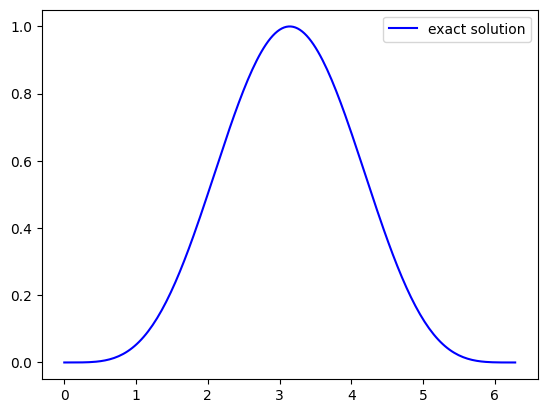

In [2]:
grid = UniformGridFcts(np.linspace(0, 2 * np.pi, 200))

exact_solution = (1-np.cos(grid.coords[0]))**2/4 
plt.figure()
plt.plot(grid.coords[0],exact_solution,color="blue",label='exact solution')
plt.legend()
plt.show()

## Regularization Methods

In [3]:
from regpy.hilbert import L2, Sobolev
from regpy.functionals import HilbertNorm, TV
from regpy.solvers import RegularizationSetting
import regpy.stoprules as rules

### Tikhonov
Requires a linear operator hence we use Volterra with exponent $n=1$. As a regularization setting use $L^2$ both as penalty and data fidelity. 

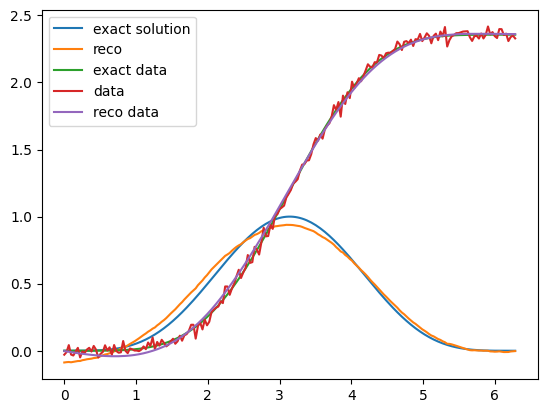

In [4]:
from regpy.solvers.linear.tikhonov import TikhonovCG

op = Volterra(grid)

exact_data = op(exact_solution)
noise = 0.03 * op.domain.randn()
data = exact_data + noise

setting = RegularizationSetting(op, L2, L2)

solver = TikhonovCG(setting, data, regpar=0.01)
stoprule = (
    rules.CountIterations(1000) +
    rules.Discrepancy(
        setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(noise),
        tau=1.1
    )
)

reco, reco_data = solver.run(stoprule)

plt.plot(grid.coords[0], exact_solution.T, label='exact solution')
plt.plot(grid.coords[0], reco, label='reco')
plt.plot(grid.coords[0], exact_data, label='exact data')
plt.plot(grid.coords[0], data, label='data')
plt.plot(grid.coords[0], reco_data, label='reco data')
plt.legend()
plt.show()

### Landweber Iteration 
Here we use a standard Sobolev norm on the domain as penalty term since the exact solution is smooth. 

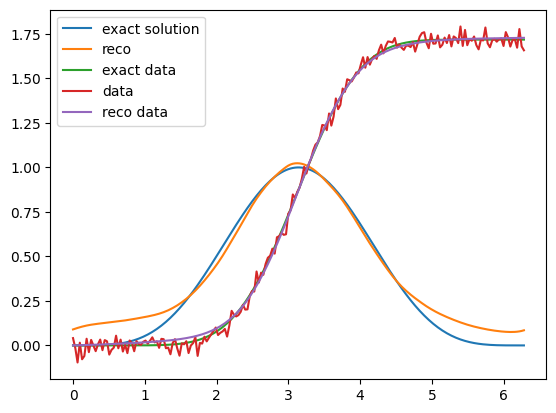

In [5]:
from regpy.solvers.nonlinear.landweber import Landweber

op = Volterra(grid,exponent=2)

exact_data = op(exact_solution)
noise = 0.03 * op.domain.randn()
data = exact_data + noise
init = op.domain.ones()*0.05

setting = RegularizationSetting(op, Sobolev, L2)

landweber = Landweber(setting, data, init, stepsize=0.01)
stoprule = (
    # Landweber is slow, so need to use large number of iterations
    rules.CountIterations(max_iterations=100000) +
    rules.Discrepancy(
        setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(noise),
        tau=1.1
    )
)

reco, reco_data = landweber.run(stoprule)

plt.plot(grid.coords[0], exact_solution.T, label='exact solution')
plt.plot(grid.coords[0], reco, label='reco')
plt.plot(grid.coords[0], exact_data, label='exact data')
plt.plot(grid.coords[0], data, label='data')
plt.plot(grid.coords[0], reco_data, label='reco data')
plt.legend()
plt.show()

### FISTA

FISTA is implemented with Impulsive noise in the middle of the interval. For a good reconstruction even with the impulsive noise use the `TV` penalty with `Sobolev` norm as penalty. For the data fidelity use the standard `L2` data fidelity. Note that this example demonstrates that you can define `AbstractFunctional` on Hilbertspace of type `AbstractSpace` by simply writing `HilbertNorm(h_space= AbstractSpace)` and you may compose this instances with operators by multiplying the operator from the right side. 

<class 'regpy.operators.OuterShift'>


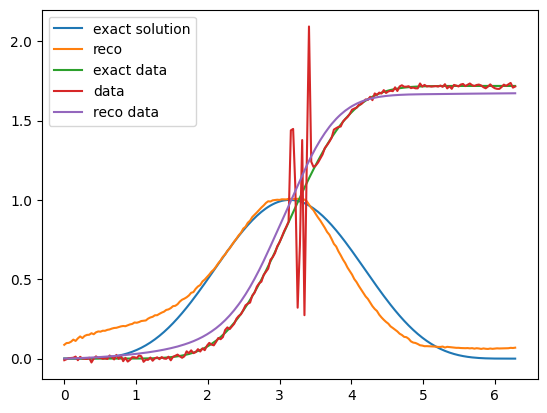

In [6]:
from regpy.solvers.nonlinear.fista import FISTA

op = Volterra(grid, exponent=2)

# Impulsive Noise
sigma = 0.01*np.ones(grid.coords.shape[1])
sigma[100:110] = 0.5

exact_data = op(exact_solution)
noise = sigma * op.domain.randn()
data = exact_data + noise
init = op.domain.ones()*0.0005

data_fidelity_operator = op - data
print(type(data_fidelity_operator))
setting = RegularizationSetting(
    op=op, 
    penalty=TV(h_domain=Sobolev), 
    data_fid=HilbertNorm(h_space=L2) * data_fidelity_operator
)


data_fidelity = setting.data_fid
"""The penalty term: 1/2 * ||f||_{TV}^2"""
penalty = setting.penalty

proximal_pars = {
        'stepsize' : 0.001,
        'maxiter' : 100
        }
# """Parameters for the inner computation of the proximal operator with the Chambolle algorithm"""

tau = 0.01
alpha = 0.01

solver = FISTA(setting, init, tau = tau, regpar = alpha, proximal_pars=proximal_pars)
stoprule = (
    # Method is slow, so need to use large number of iterations
    rules.CountIterations(max_iterations=100000) +
    rules.Discrepancy(
        setting.h_codomain.norm, data,
        noiselevel=setting.h_codomain.norm(noise),
        tau=1.1
    )
)

reco, reco_data = solver.run(stoprule)

plt.plot(grid.coords[0], exact_solution.T, label='exact solution')
plt.plot(grid.coords[0], reco, label='reco')
plt.plot(grid.coords[0], exact_data, label='exact data')
plt.plot(grid.coords[0], data, label='data')
plt.plot(grid.coords[0], reco_data, label='reco data')
plt.legend()
plt.show()
